In [14]:
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyvalet import ValetInterpreter


In [2]:
vi = ValetInterpreter()

In [3]:
# V39079: Bank of Canada Policy Target Rate (Interest Rate)
# V41690973: Consumer Price Index (CPI) Total, Monthly, Not Seasonally Adjusted
series_map = {
    "policy_interest_rate" : "V39079",
    "cpi_total" : "V41690973"
}

# Raw Target Overnight Interest Rate Data
target_overnight_interest_rate = vi.get_series_observations(series_map["policy_interest_rate"], "csv").drop(np.nan, axis=1)
target_overnight_interest_rate = target_overnight_interest_rate.rename(columns={"date": "Date", "V39079": "Interest Rate"})
target_overnight_interest_rate["Date"] = pd.to_datetime(target_overnight_interest_rate["Date"])
target_overnight_interest_rate["Interest Rate"] = pd.to_numeric(target_overnight_interest_rate["Interest Rate"])

# Raw Consumer Price Index
consumer_price_index = vi.get_series_observations(series_map["cpi_total"], "csv").drop(np.nan, axis=1)
consumer_price_index = consumer_price_index.rename(columns={"date": "Date", "V41690973": "Consumer Price Index"})
consumer_price_index["Date"] = pd.to_datetime(consumer_price_index["Date"])
consumer_price_index["Consumer Price Index"] = pd.to_numeric(consumer_price_index["Consumer Price Index"])

In [4]:
# Inorder to plot the two dataframes on the same plot we need to align them and merge
cpi_w_interest_rate = pd.merge(target_overnight_interest_rate, consumer_price_index, on="Date", how="inner")

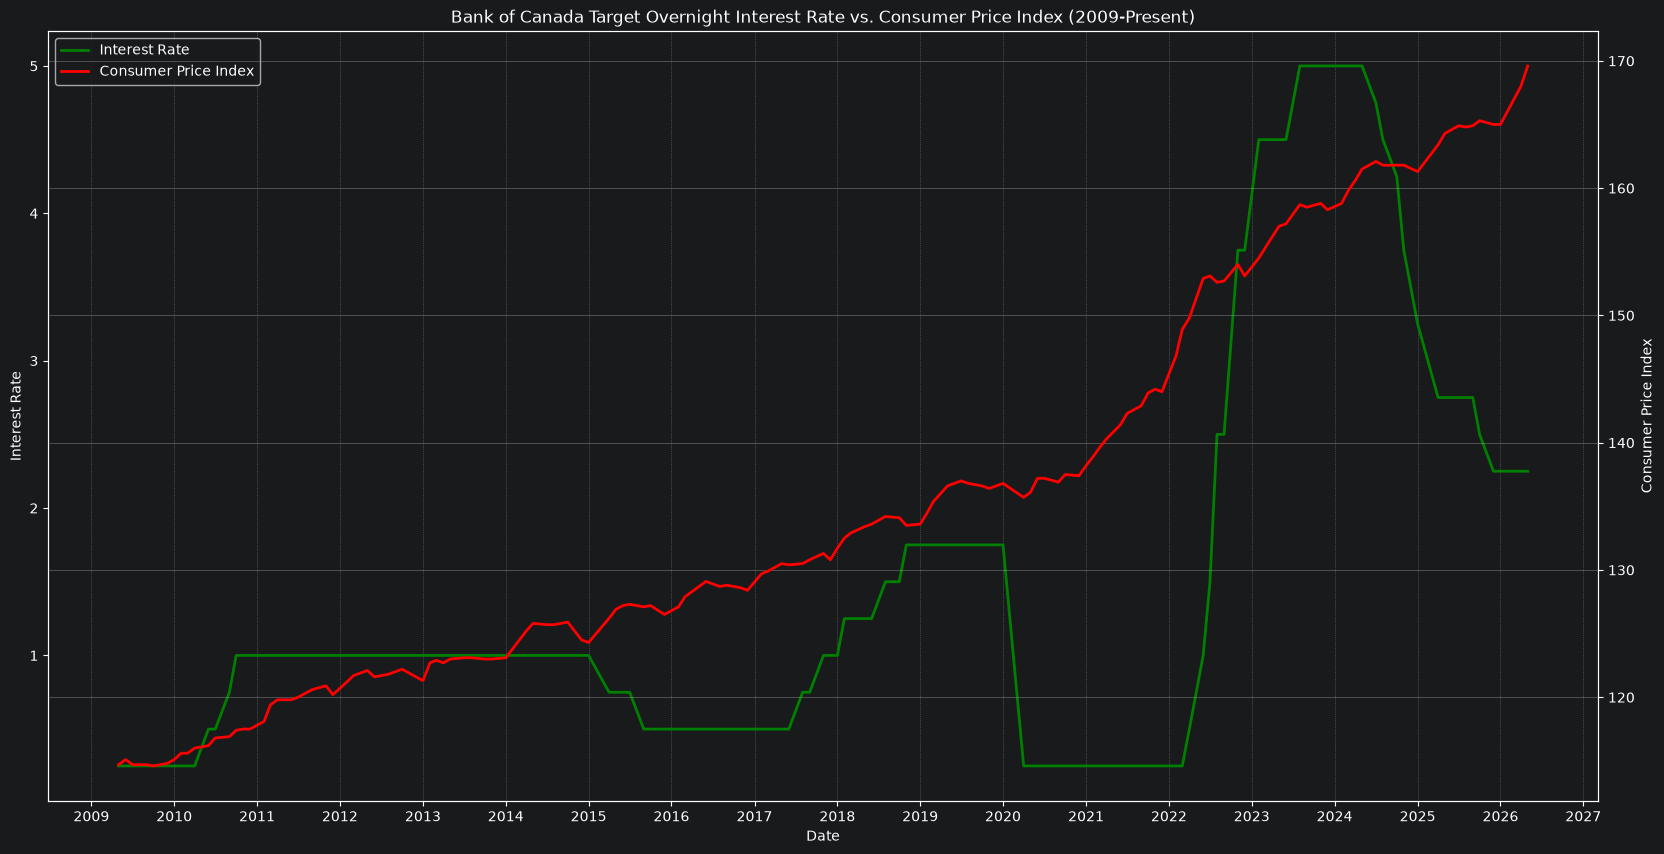

In [17]:
fig, ax1 = plt.subplots(figsize=(20,10))

# Interest Rate Line
ax1.set_xlabel("Date")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, which='major', axis='x', linestyle=':', alpha=0.6)
ax1.plot(cpi_w_interest_rate["Date"], cpi_w_interest_rate["Interest Rate"], color='g', linewidth='2', label="Interest Rate")
ax1.set_ylabel("Interest Rate")

# Consumer Price Line
ax2 = ax1.twinx()
ax2.plot(cpi_w_interest_rate["Date"], cpi_w_interest_rate["Consumer Price Index"], color='r', linewidth='2', label="Consumer Price Index")
ax2.grid(True)
ax2.set_ylabel("Consumer Price Index")

# Combine both line labels so they display in a single legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Bank of Canada Target Overnight Interest Rate vs. Consumer Price Index (2009-Present)")
plt.show()

In [6]:
consumer_price_index["Inflation Rate"] = consumer_price_index["Consumer Price Index"].pct_change(periods=12)*100
consumer_price_index = consumer_price_index.dropna()

cpi_inflation_interest = pd.merge(target_overnight_interest_rate, consumer_price_index, on="Date", how="inner")

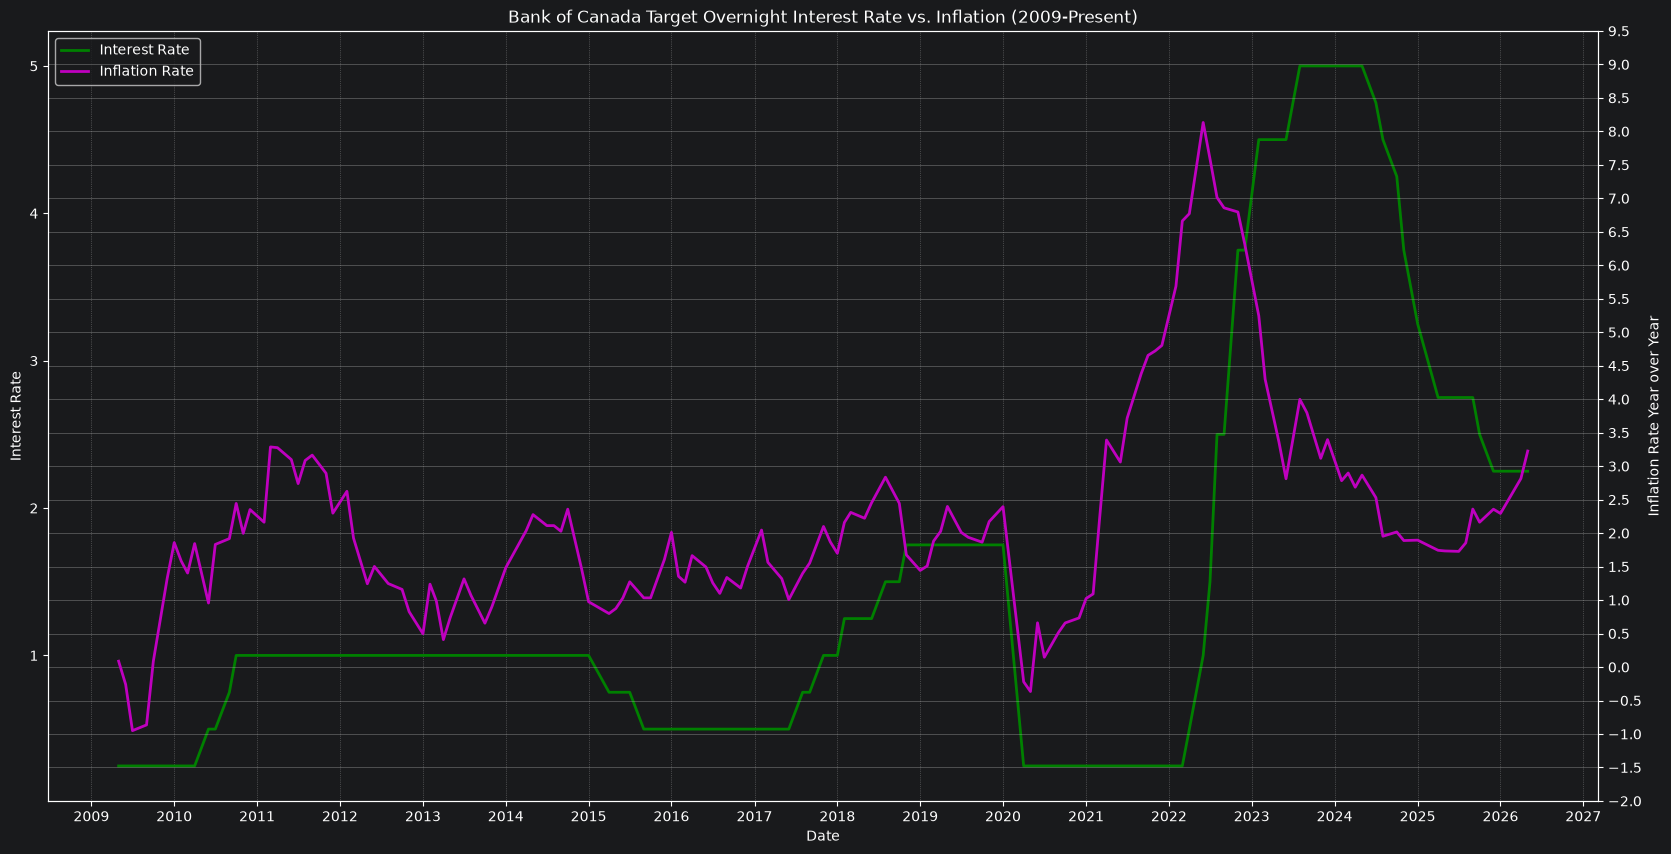

In [15]:
fig, ax1 = plt.subplots(figsize=(20,10))

# Interest Rate Line
ax1.set_xlabel("Date")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, which='major', axis='x', linestyle=':', alpha=0.6)
ax1.plot(cpi_inflation_interest["Date"], cpi_inflation_interest["Interest Rate"], color='g', linewidth='2', label="Interest Rate")
ax1.set_ylabel("Interest Rate")

# Consumer Price Line
ax2 = ax1.twinx()
ax2.plot(cpi_inflation_interest["Date"], cpi_inflation_interest["Inflation Rate"], color='m', linewidth='2', label="Inflation Rate")
ax2.set_yticks(np.arange(-2, 10, 0.5))
ax2.grid(True)
ax2.set_ylabel("Inflation Rate Year over Year")

# Combine both line labels so they display in a single legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Bank of Canada Target Overnight Interest Rate vs. Inflation (2009-Present)")
plt.show()

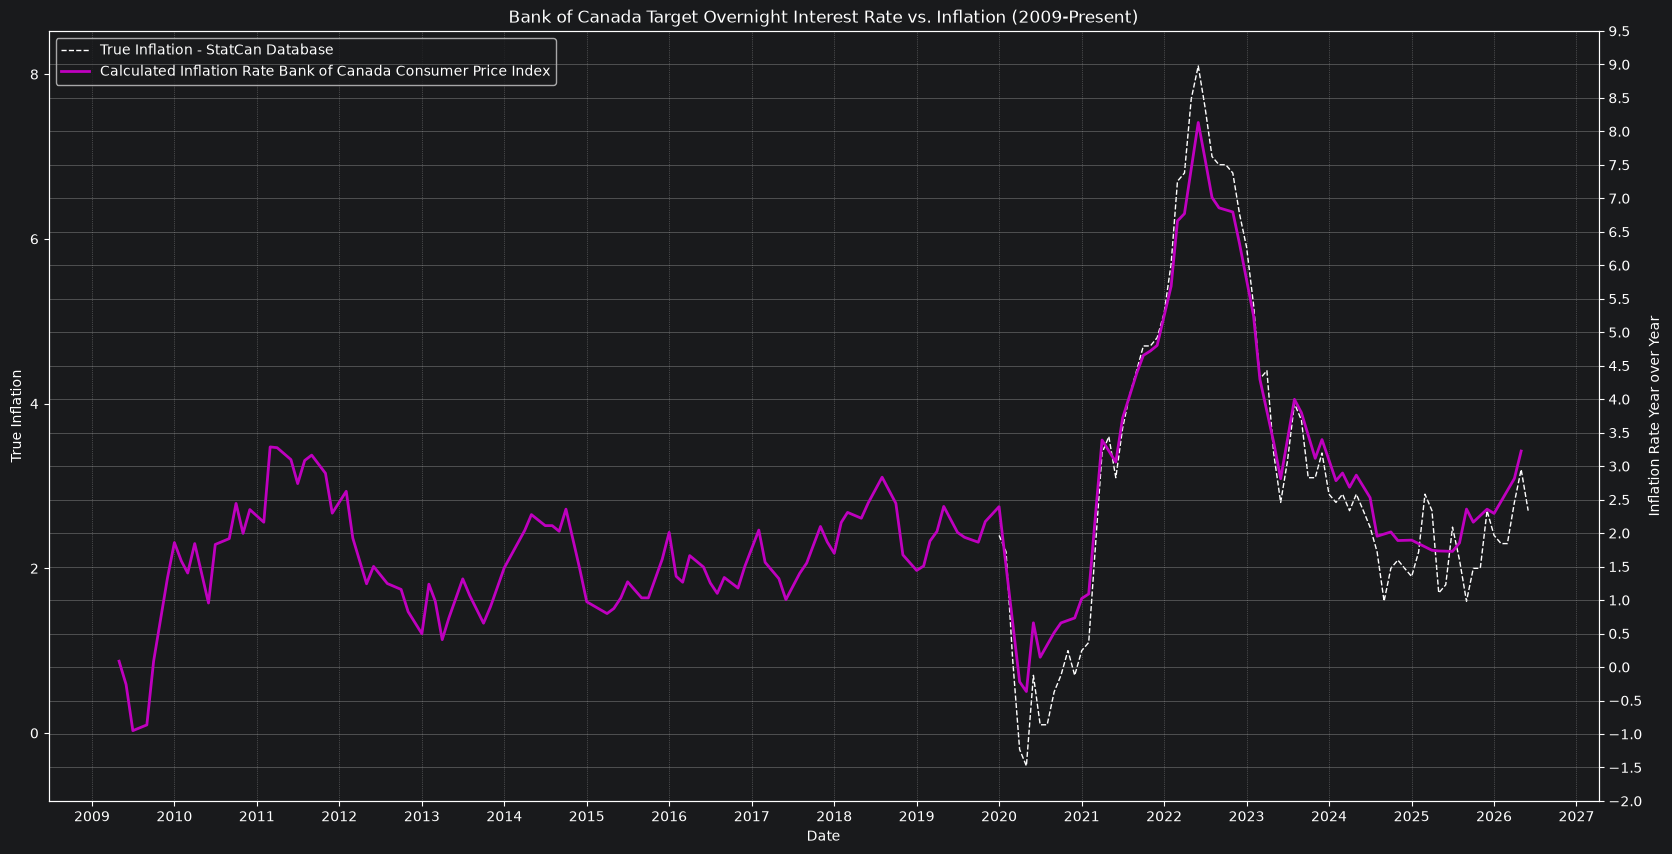

In [16]:
#Inflation data obtained through statistics Canada
dates = [
    # 2020
    "2020-01-01", "2020-02-01", "2020-03-01", "2020-04-01", "2020-05-01", "2020-06-01",
    "2020-07-01", "2020-08-01", "2020-09-01", "2020-10-01", "2020-11-01", "2020-12-01",
    # 2021
    "2021-01-01", "2021-02-01", "2021-03-01", "2021-04-01", "2021-05-01", "2021-06-01",
    "2021-07-01", "2021-08-01", "2021-09-01", "2021-10-01", "2021-11-01", "2021-12-01",
    # 2022
    "2022-01-01", "2022-02-01", "2022-03-01", "2022-04-01", "2022-05-01", "2022-06-01",
    "2022-07-01", "2022-08-01", "2022-09-01", "2022-10-01", "2022-11-01", "2022-12-01",
    # 2023
    "2023-01-01", "2023-02-01", "2023-03-01", "2023-04-01", "2023-05-01", "2023-06-01",
    "2023-07-01", "2023-08-01", "2023-09-01", "2023-10-01", "2023-11-01", "2023-12-01",
    # 2024
    "2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-06-01",
    "2024-07-01", "2024-08-01", "2024-09-01", "2024-10-01", "2024-11-01", "2024-12-01",
    # 2025
    "2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01", "2025-05-01", "2025-06-01",
    "2025-07-01", "2025-08-01", "2025-09-01", "2025-10-01", "2025-11-01", "2025-12-01",
    # 2026
    "2026-01-01", "2026-02-01", "2026-03-01", "2026-04-01", "2026-05-01", "2026-06-01"
]

inflation_rates = [
    2.4, 2.2, 0.9, -0.2, -0.4, 0.7, 0.1, 0.1, 0.5, 0.7, 1.0, 0.7,
    1.0, 1.1, 2.2, 3.4, 3.6, 3.1, 3.7, 4.1, 4.4, 4.7, 4.7, 4.8,
    5.1, 5.7, 6.7, 6.8, 7.7, 8.1, 7.6, 7.0, 6.9, 6.9, 6.8, 6.3,
    5.9, 5.2, 4.3, 4.4, 3.4, 2.8, 3.3, 4.0, 3.8, 3.1, 3.1, 3.4,
    2.9, 2.8, 2.9, 2.7, 2.9, 2.7, 2.5, 2.2, 1.6, 2.0, 2.1, 2.0,
    1.9, 2.2, 2.9, 2.7, 1.7, 1.8, 2.5, 2.1, 1.6, 2.0, 2.0, 2.7,
    2.4, 2.3, 2.3, 2.8, 3.2, 2.7
]

# 2. Assemble the two-column DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Inflation_Rate': inflation_rates
})

df["Date"] = pd.to_datetime(df["Date"])

fig, ax1 = plt.subplots(figsize=(20,10))

# Interest Rate Line
ax1.set_xlabel("Date")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, which='major', axis='x', linestyle=':', alpha=0.6)
ax1.plot(df["Date"], df["Inflation_Rate"], color='w', linewidth='1', linestyle="--", label="True Inflation - StatCan Database")
ax1.set_ylabel("True Inflation")

# Consumer Price Line
ax2 = ax1.twinx()
ax2.plot(cpi_inflation_interest["Date"], cpi_inflation_interest["Inflation Rate"], color='m', linewidth='2', label="Calculated Inflation Rate Bank of Canada Consumer Price Index")
ax2.set_yticks(np.arange(-2, 10, 0.5))
ax2.grid(True)
ax2.set_ylabel("Inflation Rate Year over Year")

# Combine both line labels so they display in a single legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Bank of Canada Target Overnight Interest Rate vs. Inflation (2009-Present)")
plt.show()